In [1]:
import fastf1
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('cache')

NotADirectoryError: Cache directory does not exist! Please check for typos or create it first.

In [8]:
session = fastf1.get_session(2025, 'Monza', 'R')
session.load()

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data f

In [9]:
driver = 'NOR'
lap = session.laps.pick_driver(driver).pick_fastest()
telemetry = lap.get_telemetry()
telemetry.head()

c:\Users\Vikas Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2025-09-07 14:15:57.656,0 days 02:10:12.743000,,1228.676944,0 days 00:00:00,11218.659986,317.059999,8,99.0,False,0,interpolation,0.046865,0.000008,OnTrack,-1383.396314,-799.762786,1870.895576
3,2025-09-07 14:15:57.676,0 days 02:10:12.763000,,1228.676944,0 days 00:00:00.020000,11220.859986,317.259999,8,99.0,False,0,pos,1.814291,0.000314,OnTrack,-1382.000000,-782.000000,1871.000000
4,2025-09-07 14:15:57.750,0 days 02:10:12.837000,,1228.676944,0 days 00:00:00.094000,11229.000000,318.000000,8,99.0,False,0,car,8.362222,0.001449,OnTrack,-1376.836606,-715.842823,1871.392697
5,2025-09-07 14:15:57.876,0 days 02:10:12.963000,,1228.676944,0 days 00:00:00.220000,11251.119113,318.789968,8,99.0,False,0,pos,19.541786,0.003386,OnTrack,-1368.000000,-605.000000,1872.000000
6,2025-09-07 14:15:58.069,0 days 02:10:13.156000,1,1228.676944,0 days 00:00:00.413000,11285.000000,320.000000,8,99.0,False,0,car,36.717778,0.006363,OnTrack,-1353.934274,-449.399248,1872.501550


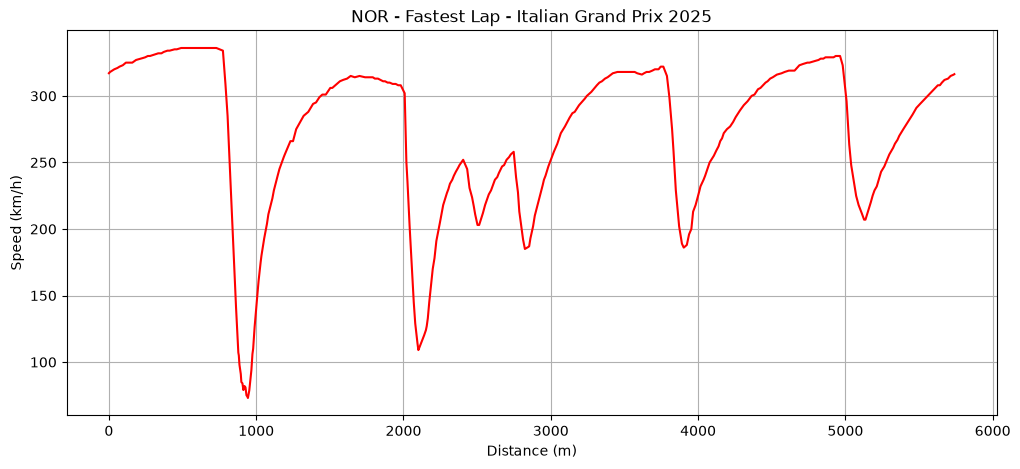

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(telemetry['Distance'], telemetry['Speed'], color='red')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')
plt.title(f'{driver} - Fastest Lap - {session.event["EventName"]} {session.event.year}')
plt.grid(True)
plt.show()

c:\Users\Vikas Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
c:\Users\Vikas Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


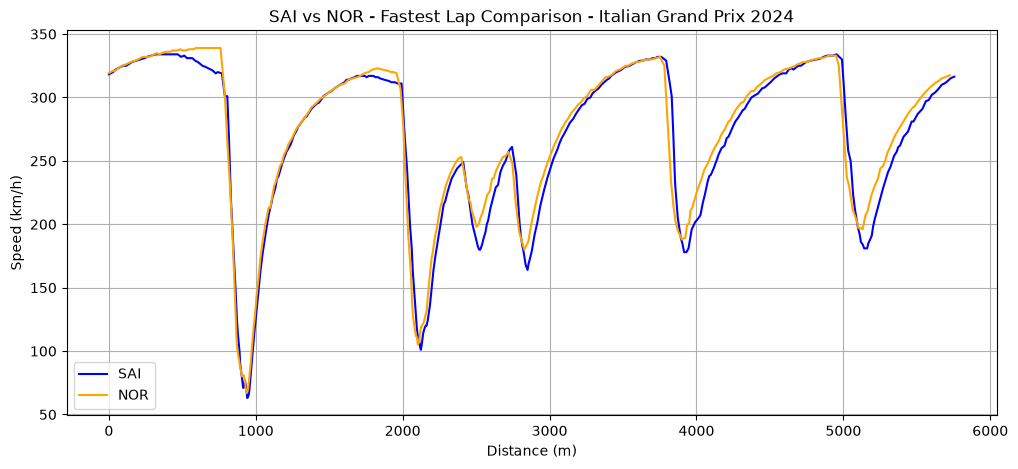

In [6]:
driver1 = 'SAI'
driver2 = 'NOR'

lap1 = session.laps.pick_driver(driver1).pick_fastest()
lap2 = session.laps.pick_driver(driver2).pick_fastest()

tel1 = lap1.get_telemetry()
tel2 = lap2.get_telemetry()

plt.figure(figsize=(12, 5))
plt.plot(tel1['Distance'], tel1['Speed'], label=driver1, color='blue')
plt.plot(tel2['Distance'], tel2['Speed'], label=driver2, color='orange')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')
plt.title(f'{driver1} vs {driver2} - Fastest Lap Comparison - {session.event["EventName"]} {session.event.year}')
plt.legend()
plt.grid(True)
plt.show()

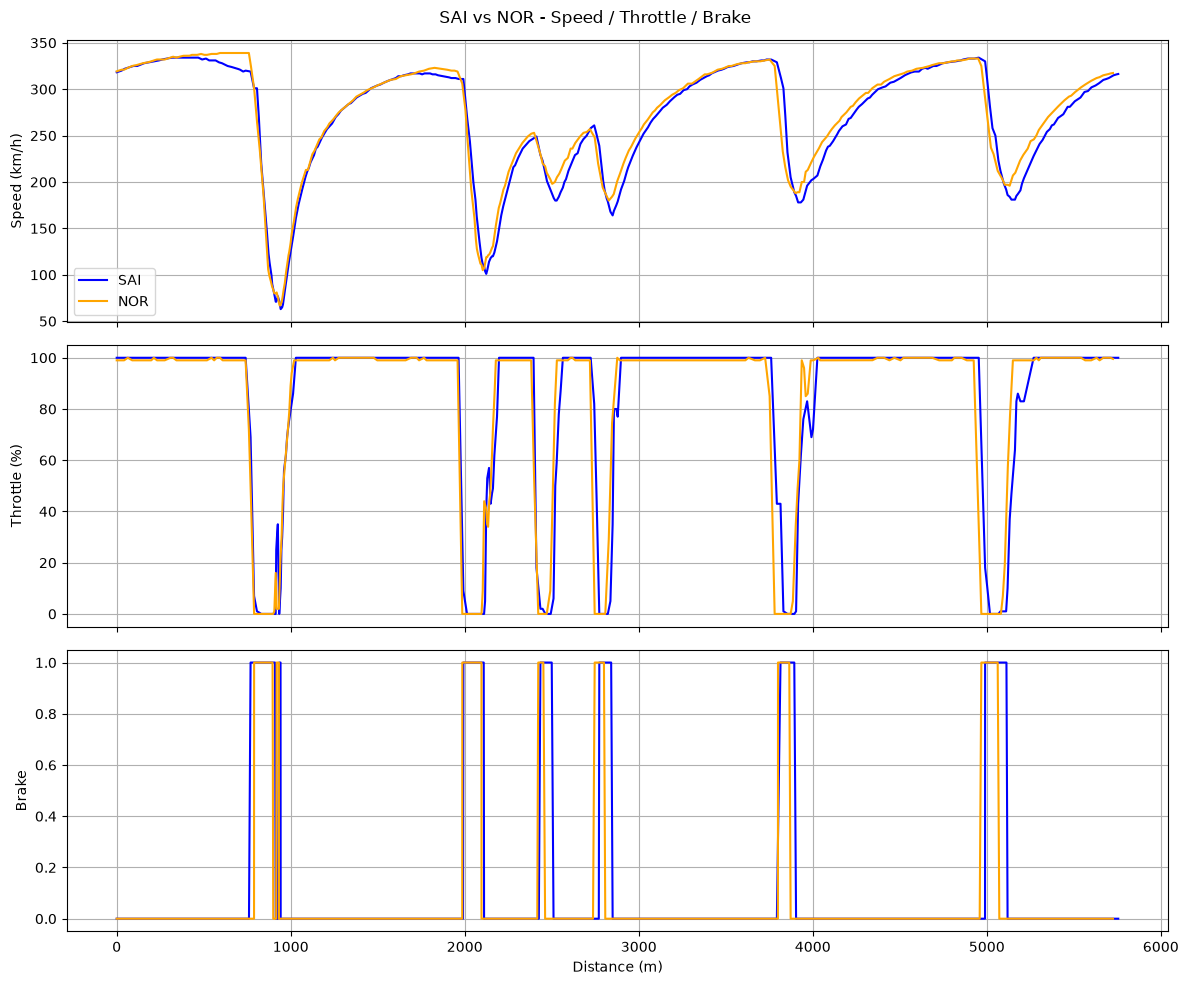

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(tel1['Distance'], tel1['Speed'], label=driver1, color='blue')
axes[0].plot(tel2['Distance'], tel2['Speed'], label=driver2, color='orange')
axes[0].set_ylabel('Speed (km/h)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(tel1['Distance'], tel1['Throttle'], color='blue')
axes[1].plot(tel2['Distance'], tel2['Throttle'], color='orange')
axes[1].set_ylabel('Throttle (%)')
axes[1].grid(True)

axes[2].plot(tel1['Distance'], tel1['Brake'], color='blue')
axes[2].plot(tel2['Distance'], tel2['Brake'], color='orange')
axes[2].set_ylabel('Brake')
axes[2].set_xlabel('Distance (m)')
axes[2].grid(True)

plt.suptitle(f'{driver1} vs {driver2} - Speed / Throttle / Brake')
plt.tight_layout()
plt.show()

In [11]:
# Compare fastest lap times and sector times between the two drivers
comparison = session.laps.pick_driver([driver1, driver2]).pick_fastest_per_driver() if hasattr(session.laps, 'pick_fastest_per_driver') else None

# Safer, explicit approach:
lap1_info = lap1[['Driver', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Compound']]
lap2_info = lap2[['Driver', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Compound']]

import pandas as pd
summary = pd.DataFrame([lap1_info, lap2_info])
summary

,Driver,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound
0,SAI,0 days 00:01:23.219000,0 days 00:00:27.463000,0 days 00:00:28.237000,0 days 00:00:27.519000,HARD
1,NOR,0 days 00:01:21.432000,0 days 00:00:27.136000,0 days 00:00:27.492000,0 days 00:00:26.804000,HARD


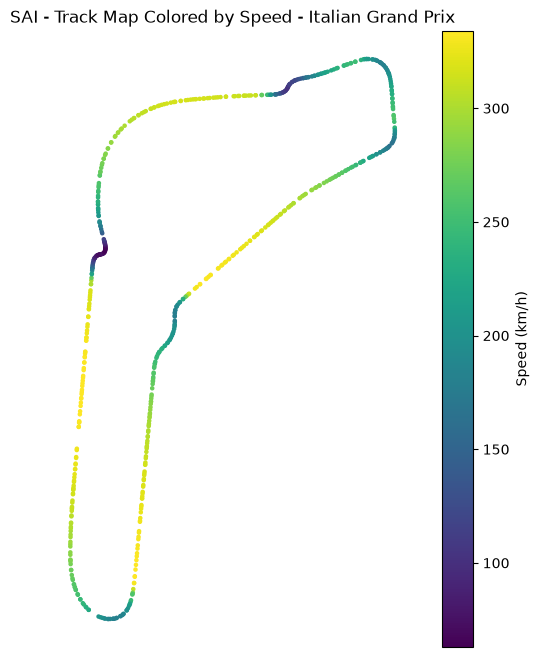

In [12]:
# Track map colored by speed (using driver1's lap)
fig, ax = plt.subplots(figsize=(8, 8))

points = ax.scatter(tel1['X'], tel1['Y'], c=tel1['Speed'], cmap='viridis', s=5)
plt.colorbar(points, label='Speed (km/h)')
ax.set_title(f'{driver1} - Track Map Colored by Speed - {session.event["EventName"]}')
ax.set_aspect('equal')
ax.axis('off')
plt.show()

c:\Users\Vikas Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


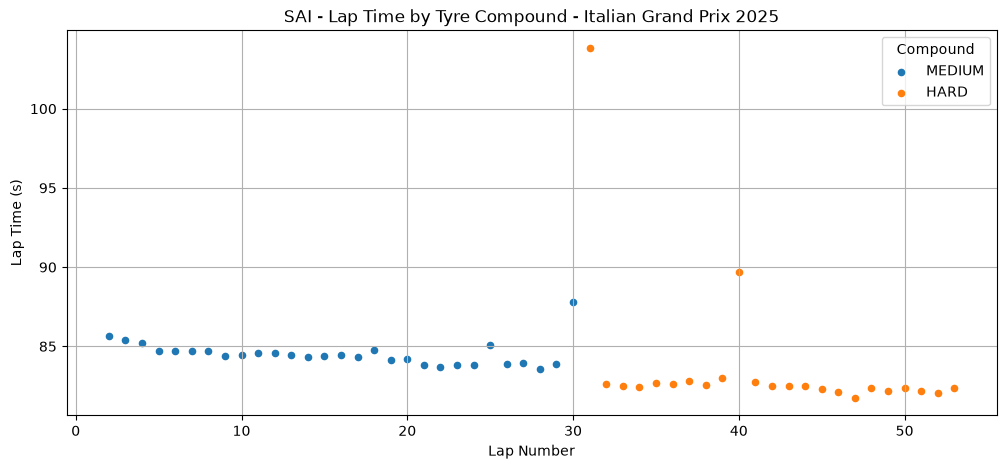

In [13]:
# Tyre stint analysis for one driver across the whole race
driver_stints = session.laps.pick_driver(driver1)

plt.figure(figsize=(12, 5))
for compound in driver_stints['Compound'].unique():
    stint_laps = driver_stints[driver_stints['Compound'] == compound]
    plt.scatter(stint_laps['LapNumber'], stint_laps['LapTime'].dt.total_seconds(), label=compound, s=20)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (s)')
plt.title(f'{driver1} - Lap Time by Tyre Compound - {session.event["EventName"]} {session.event.year}')
plt.legend(title='Compound')
plt.grid(True)
plt.show()